In [28]:
SCALE = 1 << 64
import math

def divide_newton(a: int, b: int) -> int:
    """
    floor(a / b) usando Newton-Raphson.

    x approssima:
        1/b  in formato Q64
    """

    if b == 0:
        raise ZeroDivisionError()

    # x ≈ 1/b in Q64
    x = (1 << 32)

    # iterazioni fisse
    for _ in range(100):

        # bx in Q64
        bx = (b * x)

        # Newton:
        # x <- x * (2 - b*x)
        #
        # tutto in Q64:
        x = (x * ((2 << 64) - bx)) >> 64

    # q = a*x
    q = (a * x) >> 64

    return q


# -------------------
# esempio
# -------------------

a = 13252352503   # 11
b = 3123

q = divide_newton(a, b)

print(q)
print(math.floor(a/b))

4243468
4243468


---

Con hint iniziale di Chebyshev

In [30]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [31]:
def inv(x):
    return 1 / x

5.99943738910369e-07

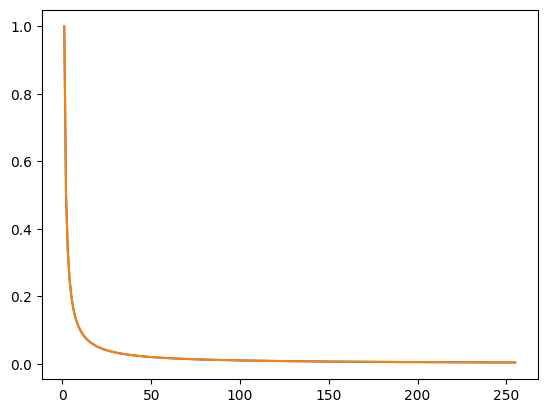

In [932]:
c = Chebyshev(1, 256, 119, inv)

x = np.arange(1, 256, 1)

y = np.vectorize(c.eval)(x)
y_real = np.vectorize(inv)(x)

plt.plot(x, y)
plt.plot(x, y_real)

max(abs(y - y_real))

In [1014]:
bits_approx = 8

def compute_hint(x):
    n = x.bit_length()
    
    u = (x >> (n - bits_approx)) & 0x3FF
    
    u += 1  
    
    r = c.eval(u)          
    
    scale = 1 << (n - bits_approx)
    
    return int(r / scale * (1 << 64)) 

In [1018]:
import math

def compute_hint(x: int) -> int:
    """Ritorna Q64 ≈ 2^64 / x usando l'approssimazione Chebyshev su [1,256]."""
    n = x.bit_length()
    
    shift = n - 8
    
    u = (x >> shift) & 0xFF

    r = c.eval(float(u))        
    
    scalefactor = (1 << (64 - shift))
    
    return int(r * scalefactor)


def divide_newton(a: int, b: int, hint_q64: int) -> int:
    x = hint_q64

    for _ in range(0):           
        residuo = b * x
        correzione = (2 << 64) - residuo
        x = (x * correzione) >> 64

    q = (a * x) >> 64
    
    #while (q + 1) * b <= a:
        #A volte ne fa 1
    #    q += 1
        
    return q


# --- test ---
a = random.getrandbits(64)
b = random.getrandbits(64)

#Funziona se b ha almeno 8 bit

hint = compute_hint(b)
q    = divide_newton(a, b, hint)

print("Newton :", q)
print("Esatto :", math.floor(a / b))
print("Errore :", q - math.floor(a / b))

Newton : 0
Esatto : 1
Errore : -1


In [880]:
return int(r * (1 << (64 - shift)))

1048576

In [818]:
2310 >> 64

0

In [930]:
hint

92233720368568960

In [1031]:
LUT = [0] + [int((1 << 64) / u) for u in range(1, 256)]  # LUT[0] inutilizzato

def compute_hint(x: int) -> int:
    """Ritorna Q64 ≈ 2^64 / x usando LUT su [1,255]."""
    n = x.bit_length()
    shift = n - 8
    u = (x >> shift) & 0xFF
    print("Input della LUT", u)
    return LUT[u] >> shift

In [1131]:
a = random.getrandbits(64)
b = random.getrandbits(64)

#Funziona se b ha almeno 8 bit

hint = compute_hint(b)
q    = divide_newton(a, b, hint)

print("Newton :", q)
print("Esatto :", math.floor(a / b))
print("Errore :", q - math.floor(a / b))

Input della LUT 248
Newton : 0
Esatto : 0
Errore : 0


In [ ]:
# L'idea è fare in modo che Cheby restituisca i binari, come una polynomial LUT